# Session 5, Notebook 2: IRBC with DEQNs, Irreversible Investment

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 1, 15:40-16:30, Scaling up: IRBC with DEQNs
**Slides:** `05_IRBC.pdf`
**Author:** Simon Scheidegger (HEC, University of Lausanne)

**Model.** Brumm and Scheidegger (2017), *Using Adaptive Sparse Grids to Solve High-Dimensional Dynamic Models*, Econometrica 85(5), section 4.1 and Appendix C. Parameters follow their Table II. One normalization differs: the Pareto weights are $\tau_j = c_{ss}^{1/\gamma_j}$ rather than $A^{1/\gamma_j}$, so that the multiplier on the resource constraint is $\lambda = 1$ at the deterministic steady state.

**Reference solution.** The last section compares the trained network with an adaptive-sparse-grid time-iteration solution of the same model, computed with the code that accompanies Brumm, Krause, Schaab and Scheidegger (2022) and stored in `reference/`.

In [1]:
RUN_MODE = "teaching"  # one of: "smoke", "teaching", "production"
SEED = 0

This notebook solves the $N$-country international real business cycle model with complete markets, productivity risk, convex capital adjustment costs, and irreversible investment: $I_t^j = k_{t+1}^j - (1-\delta)k_t^j \ge 0$. The state is

$$
  s_t=(k_t^1,\ldots,k_t^N,\,z_t^1,\ldots,z_t^N),\qquad z_t^j=\log a_t^j,
$$

and the policy network returns next-period capital, the multiplier on the world resource constraint, and one Kuhn-Tucker multiplier per country,

$$
  p(s_t)=\big(k_{t+1}^1,\ldots,k_{t+1}^N,\;\lambda_t,\;\mu_t^1,\ldots,\mu_t^N\big),
  \qquad 0\le \mu_t^j \perp I_t^j \ge 0 .
$$

Feasibility is built into the network: it chooses an investment fraction $I^j/k^j \in (0, \bar\iota)$ through a sigmoid, so no simulated state can violate irreversibility. Complementarity enters the loss through a smoothed Fischer-Burmeister residual. Everything else, the training-data construction, the diagnostics and the comparison with the sparse-grid solution, is as in `05_01`.

In [2]:
import math
import time
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 13
T_NOTEBOOK_START = time.perf_counter()

np.random.seed(SEED)
tf.random.set_seed(SEED)
rng = np.random.default_rng(SEED)

# Where the training states come from.
#   "simulation": states visited by trajectories simulated under the current policy (default)
#   "exogenous" : uniform draws from a fixed box, for the comparison of Session 4
SAMPLING_MODE = "simulation"

# Training budget.  One segment = one simulation of all trajectory heads
# followed by PASSES_PER_SEGMENT passes of mini-batch Adam over the visited states.
if RUN_MODE == "smoke":
    NUM_SEGMENTS = 61
    N_TRAJECTORIES = 4
    SIMULATION_LENGTH = 128
    BATCH_SIZE = 128
    PASSES_PER_SEGMENT = 2
    MONITOR_EVERY = 5
elif RUN_MODE == "teaching":
    NUM_SEGMENTS = 401
    N_TRAJECTORIES = 10
    SIMULATION_LENGTH = 256
    BATCH_SIZE = 512
    PASSES_PER_SEGMENT = 4
    MONITOR_EVERY = 10
elif RUN_MODE == "production":
    NUM_SEGMENTS = 1201
    N_TRAJECTORIES = 32
    SIMULATION_LENGTH = 512
    BATCH_SIZE = 1024
    PASSES_PER_SEGMENT = 4
    MONITOR_EVERY = 25
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

# Learning rate by segment: large while the policy is far from the solution,
# then two reductions.  'until' is exclusive.
LR_SCHEDULE = [
    dict(until=int(0.4 * NUM_SEGMENTS), learning_rate=1e-3),
    dict(until=int(0.8 * NUM_SEGMENTS), learning_rate=1e-4),
    dict(until=NUM_SEGMENTS, learning_rate=1e-5),
]
SHUFFLE_STATES_WITHIN_SEGMENT = True
ADAM_BETA_1 = 0.9
ADAM_BETA_2 = 0.999
CLIP_NORM = 10.0                 # global gradient-norm clipping; None to disable

# Loss weights.  All residuals are unit-free, so equal weights are the natural start.
EULER_WEIGHT = 1.0
ARC_WEIGHT = 1.0
FB_WEIGHT = 1.0

# Exogenous sampling uses as many states per segment as one simulated segment.
EXOGENOUS_STATES_PER_SEGMENT = N_TRAJECTORIES * SIMULATION_LENGTH

# Runaway guard.  A trajectory head that leaves the admissible box (set from the
# sampling boxes in the next cell) is replaced by a fresh draw from the initial
# box.  Every replacement is counted and printed as 'repairs' in the training log.
EMERGENCY_REPAIR_BAD_STATES = True

# Diagnostics.
if RUN_MODE == "smoke":
    TIME_INVARIANCE_ANCHOR_STATES = 512
    ZERO_SHOCK_N_STARTS = 8
    N_EVAL_BOX = 2048
    N_EVAL_TRACKS, EVAL_BURN_IN, EVAL_LENGTH = 8, 256, 128
else:
    TIME_INVARIANCE_ANCHOR_STATES = 2048
    ZERO_SHOCK_N_STARTS = 32
    N_EVAL_BOX = 8192
    N_EVAL_TRACKS, EVAL_BURN_IN, EVAL_LENGTH = 32, 512, 256
ZERO_SHOCK_MAX_STEPS = 3000
TIME_INVARIANCE_TOL_RMS = 1.0e-3
TIME_INVARIANCE_TOL_MAX = 1.0e-2
ZERO_SHOCK_TOL = 1.0e-7
ZERO_SHOCK_FIXED_POINT_TOL = 1.0e-4
ZERO_SHOCK_Z_TOL = 1.0e-4
ZERO_SHOCK_CROSS_TRACK_TOL = 5.0e-3
SSS_MEAN_RESIDUAL_TOL = 1.0e-2
SSS_K_MIN_OK = 0.20
SSS_K_MAX_OK = 5.00

print(f"TensorFlow {tf.__version__}")
print(f"RUN_MODE = {RUN_MODE}, SAMPLING_MODE = {SAMPLING_MODE}")
print(f"segments = {NUM_SEGMENTS}, trajectories = {N_TRAJECTORIES}, segment length = {SIMULATION_LENGTH}, "
      f"states per segment = {N_TRAJECTORIES * SIMULATION_LENGTH}")
print(f"batch size = {BATCH_SIZE}, passes per segment = {PASSES_PER_SEGMENT}")
print("learning-rate schedule:", [(s["until"], s["learning_rate"]) for s in LR_SCHEDULE])

2026-09-09 09:35:13.903971: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788939313.925728  327039 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788939313.931948  327039 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-09 09:35:13.958499: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.18.0
RUN_MODE = teaching, SAMPLING_MODE = simulation
segments = 401, trajectories = 10, segment length = 256, states per segment = 2560
batch size = 512, passes per segment = 4
learning-rate schedule: [(160, 0.001), (320, 0.0001), (401, 1e-05)]


## 1. Model and parameters

Country $j$ produces $y_t^j = A\,e^{z_t^j}(k_t^j)^{\zeta}$ with

$$
  z_{t+1}^j=\rho z_t^j+\sigma\big(\varepsilon_{t+1}^j+\varepsilon_{t+1}^{\mathrm{agg}}\big),
  \qquad \varepsilon \sim N(0,1) \text{ i.i.d.},
$$

so the innovation variance of $z^j$ is $2\sigma^2$ and innovations are correlated one half across countries. Changing the capital stock costs $\Gamma_t^j = \tfrac{\kappa}{2}k_t^j\,(g_{t+1}^j)^2$ with $g_{t+1}^j = k_{t+1}^j/k_t^j - 1$. The planner maximizes $E_0\sum_t \beta^t \sum_j \tau_j\, u_j(c_t^j)$ with $u_j(c) = c^{1-1/\gamma_j}/(1-1/\gamma_j)$, subject to the world resource constraint

$$
  \sum_{j=1}^{N}\Big[y_t^j + (1-\delta)k_t^j - k_{t+1}^j - \Gamma_t^j - c_t^j\Big] = 0 .
$$

The first-order condition for $c_t^j$ is $\tau_j (c_t^j)^{-1/\gamma_j} = \lambda_t$. The first-order condition for $k_{t+1}^j$ is the Euler equation in section 4.

$A$ is chosen so that the deterministic steady state has $k = 1$; then $c_{ss} = A - \delta$ and, with $\tau_j = c_{ss}^{1/\gamma_j}$, $\lambda_{ss} = 1$. The $\gamma_j$ are spread evenly on $[0.25, 1]$ (Brumm and Scheidegger 2017, Table II).

In [3]:
N_COUNTRIES = 2

beta = 0.99      # discount factor
zeta = 0.36      # capital share
delta = 0.01     # depreciation (quarterly)
rho_z = 0.95     # persistence of log TFP
sigma_e = 0.01   # std of each shock component
kappa = 0.50     # adjustment-cost intensity (phi in the paper)

gamma_min = 0.25
gamma_max = 1.00

# Deterministic steady state normalized to k = 1:  1 = beta * (A*zeta + 1 - delta).
K_REF = 1.0
LAMBDA_REF = 1.0
A_tfp = (1.0 / beta - 1.0 + delta) / (zeta * K_REF ** (zeta - 1.0))
Y_ref = A_tfp * K_REF ** zeta
C_ref = Y_ref - delta * K_REF

if N_COUNTRIES == 1:
    gammas_np = np.array([gamma_min], dtype=np.float32)
else:
    gammas_np = np.linspace(gamma_min, gamma_max, N_COUNTRIES, dtype=np.float32)

# Planner FOC tau_j * c_j^(-1/gamma_j) = lambda; tau_j chosen so that c_j = C_ref at lambda = 1.
taus_np = LAMBDA_REF * C_ref ** (1.0 / gammas_np)

gammas_tf = tf.constant(gammas_np.reshape(1, N_COUNTRIES), dtype=tf.float32)
taus_tf = tf.constant(taus_np.reshape(1, N_COUNTRIES), dtype=tf.float32)

n_states = 2 * N_COUNTRIES      # [k_1..k_N, z_1..z_N]
n_policies = 2 * N_COUNTRIES + 1  # [k'_1..k'_N, lambda, mu_1..mu_N]
n_shocks = N_COUNTRIES + 1      # N country shocks + one aggregate shock

z_std = sigma_e * math.sqrt(2.0 / (1.0 - rho_z ** 2))
z_bound = 3.0 * z_std

# Boxes.
# Paper box: the state space of Brumm and Scheidegger (2017); used for evaluation.
PAPER_K_LOW, PAPER_K_HIGH = 0.8, 1.2
PAPER_Z_BOUND = 0.8 * sigma_e / (1.0 - rho_z)
# Wide box: exogenous training draws, holdout states, and an extrapolation check.
EXOGENOUS_K_LOW, EXOGENOUS_K_HIGH = 0.55, 1.80
EXOGENOUS_Z_LOW, EXOGENOUS_Z_HIGH = -z_bound, z_bound
# Initial trajectory heads: dispersed feasible states, not the steady state.
INITIAL_K_LOW, INITIAL_K_HIGH = 0.65, 1.45
INITIAL_Z_LOW, INITIAL_Z_HIGH = -1.5 * z_std, 1.5 * z_std
# Runaway guard, tied to the wide box.
SIM_REPAIR_K_MIN = 0.5 * EXOGENOUS_K_LOW
SIM_REPAIR_K_MAX = 2.0 * EXOGENOUS_K_HIGH
SIM_REPAIR_ABS_Z_MAX = 8.0 * z_std

print(f"N_COUNTRIES = {N_COUNTRIES}: states = {n_states}, policies = {n_policies}, shocks = {n_shocks}")
print(f"A_tfp = {A_tfp:.6f}, Y_ref = {Y_ref:.6f}, C_ref = {C_ref:.6f}")
print(f"gammas = {gammas_np}")
print(f"taus = {taus_np}")
print(f"z_std = {z_std:.5f}, paper z bound = {PAPER_Z_BOUND:.3f}")
print(f"guard: k in [{SIM_REPAIR_K_MIN:.3f}, {SIM_REPAIR_K_MAX:.3f}], |z| <= {SIM_REPAIR_ABS_Z_MAX:.3f}")

N_COUNTRIES = 2: states = 4, policies = 5, shocks = 3
A_tfp = 0.055836, Y_ref = 0.055836, C_ref = 0.045836
gammas = [0.25 1.  ]
taus = [4.413998e-06 4.583614e-02]
z_std = 0.04529, paper z bound = 0.160
guard: k in [0.275, 3.600], |z| <= 0.362


2026-09-09 09:35:17.211109: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Integration rule

Expectations over the $N+1$ shocks use the monomial rule of Brumm and Scheidegger (2017, Appendix C): $2(N+1)$ nodes at $\pm\sqrt{N+1}$ on each shock axis with equal weights. It integrates every polynomial of degree three exactly, and its cost grows linearly in $N$, against $Q^{N+1}$ for a tensor-product Gauss-Hermite rule.

In [4]:
def make_monomial_rule(dim):
    """Nodes and weights for E[f(eps)], eps ~ N(0, I_dim): +/- sqrt(dim) e_i, weight 1/(2 dim)."""
    radius = math.sqrt(dim)
    nodes, weights = [], []
    for i in range(dim):
        for sign in (1.0, -1.0):
            e = np.zeros(dim, dtype=np.float32)
            e[i] = sign * radius
            nodes.append(e)
            weights.append(1.0 / (2.0 * dim))
    return np.asarray(nodes, dtype=np.float32), np.asarray(weights, dtype=np.float32)

quad_nodes_np, quad_weights_np = make_monomial_rule(n_shocks)
quad_nodes_tf = tf.constant(quad_nodes_np, dtype=tf.float32)
quad_weights_tf = tf.constant(quad_weights_np.reshape(-1, 1), dtype=tf.float32)
n_quad = quad_nodes_np.shape[0]

print(f"quadrature nodes = {n_quad}, sum of weights = {quad_weights_np.sum():.6f}")

quadrature nodes = 6, sum of weights = 1.000000


## 3. Network and policy transformation

Two hidden layers of 128 tanh units and a linear output layer initialized at zero. The raw outputs are mapped to admissible policies:

$$
  \tilde k_{t+1}^j = k_t^j \exp\{\bar g \tanh r_j\}, \qquad
  k_{t+1}^j = (1-\delta)k_t^j + \mathrm{softplus}_{s}\big(\tilde k_{t+1}^j - (1-\delta)k_t^j\big), \qquad
  \lambda_t = \exp\{\bar s \tanh r_\lambda\}, \qquad \mu_t^j = \lambda_t\,\mathrm{softplus}(r_{\mu,j} + b_\mu).
$$

$\tilde k$ is the unconstrained capital choice, with the same head as in `05_01`. The smoothed maximum $\mathrm{softplus}_s(x) = s\log(1 + e^{x/s})$ with $s = 10^{-3}k$ returns $x$ itself when the constraint is slack by more than a few $s$ and a number indistinguishable from zero when $\tilde k$ falls below $(1-\delta)k$: irreversibility holds by construction, investment can be zero, and where the constraint is slack the head has the same gradient as the smooth model. Zero raw outputs give $I = \delta k$ and $\mu \approx 0$.

In [5]:
INPUT_K_LOG_SCALE = 0.50
INPUT_Z_SCALE = max(z_bound, 1e-6)
LAMBDA_LOG_SCALE = 1.25

KP_GROWTH_SCALE = 0.10       # |log(k_tilde / k)| <= 0.10 per period, as in 05_01
IRREV_SMOOTH_SCALE = 1e-3    # scale s of the smoothed maximum, relative to k
MU_SOFTPLUS_BIAS = -10.0     # softplus(-10) = 4.5e-5: multipliers start at zero

NUM_HIDDEN_1 = 128
NUM_HIDDEN_2 = 128
ACTIVATION = "tanh"

def scale_states(states):
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    k = tf.maximum(states[:, :N_COUNTRIES], 1e-8)
    z = states[:, N_COUNTRIES:]
    return tf.concat([tf.math.log(k / K_REF) / INPUT_K_LOG_SCALE, z / INPUT_Z_SCALE], axis=1)

def build_network():
    return keras.Sequential([
        keras.layers.Input(shape=(n_states,)),
        keras.layers.Dense(NUM_HIDDEN_1, activation=ACTIVATION),
        keras.layers.Dense(NUM_HIDDEN_2, activation=ACTIVATION),
        keras.layers.Dense(n_policies, activation=None, kernel_initializer="zeros", bias_initializer="zeros"),
    ])

def policy(states, model):
    """States -> (k', lambda, mu, I, I/k), all feasible by construction."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    k = tf.maximum(states[:, :N_COUNTRIES], 1e-8)
    raw = model(scale_states(states))
    raw_k = raw[:, :N_COUNTRIES]
    raw_lambda = raw[:, N_COUNTRIES:N_COUNTRIES + 1]
    raw_mu = raw[:, N_COUNTRIES + 1:]

    kp_unconstrained = k * tf.exp(KP_GROWTH_SCALE * tf.tanh(raw_k))
    k_floor = (1.0 - delta) * k
    s = IRREV_SMOOTH_SCALE * k
    investment = s * tf.nn.softplus((kp_unconstrained - k_floor) / s)    # smoothed max(0, k_tilde - (1-delta) k)
    investment_fraction = investment / k
    kp = k_floor + investment
    lamb = LAMBDA_REF * tf.exp(LAMBDA_LOG_SCALE * tf.tanh(raw_lambda))
    mu = lamb * tf.nn.softplus(raw_mu + MU_SOFTPLUS_BIAS)
    return kp, lamb, mu, investment, investment_fraction

model_check = build_network()
X_check = tf.constant(np.concatenate([np.ones((3, N_COUNTRIES), np.float32), np.zeros((3, N_COUNTRIES), np.float32)], axis=1))
kp_check, lambda_check, mu_check, I_check, Ifrac_check = policy(X_check, model_check)
print("initial k' rows:\n", kp_check.numpy())
print("initial I/k rows:\n", Ifrac_check.numpy())
print("initial mu rows:\n", mu_check.numpy())

initial k' rows:
 [[1. 1.]
 [1. 1.]
 [1. 1.]]
initial I/k rows:
 [[0.01000004 0.01000004]
 [0.01000004 0.01000004]
 [0.01000004 0.01000004]]
initial mu rows:
 [[4.53989e-05 4.53989e-05]
 [4.53989e-05 4.53989e-05]
 [4.53989e-05 4.53989e-05]]


## 4. Residuals and loss

The Euler equation for $k_{t+1}^j$ with the multiplier $\mu_t^j$ on $I_t^j \ge 0$ (Brumm and Scheidegger 2017, eq. 28) is

$$
  \lambda_t\big(1+\kappa g_{t+1}^j\big) - \mu_t^j
  = \beta E_t\Big[\lambda_{t+1}\Big(\zeta A e^{z_{t+1}^j}(k_{t+1}^j)^{\zeta-1} + 1-\delta + \tfrac{\kappa}{2}\,g_{t+2}^j(g_{t+2}^j+2)\Big) - (1-\delta)\,\mu_{t+1}^j\Big].
$$

The notebook uses three unit-free residuals per state: the Euler residual (right-hand side plus $\mu_t^j$, divided by $\lambda_t(1+\kappa g_{t+1}^j)$, minus one), the resource residual divided by aggregate resources $\sum_j [y_t^j + (1-\delta)k_t^j]$, and the smoothed Fischer-Burmeister residual

$$
  \mathrm{FB}_\varepsilon(a, b) = a + b - \sqrt{a^2 + b^2 + \varepsilon^2}, \qquad a = \mu_t^j/\lambda_t, \; b = I_t^j/k_t^j,
$$

whose zero set at $\varepsilon = 0$ is exactly $a \ge 0$, $b \ge 0$, $ab = 0$. Where the constraint is slack, $\mathrm{FB}_\varepsilon \approx a = \mu/\lambda$, and $\mu$ sits at the floor of its softplus head ($4.5 \times 10^{-5}$ at zero raw output), so the mean of $|\mathrm{FB}|$ measures that floor rather than complementarity; the product $ab$, reported alongside it, is the informative number. The loss is the sum of the three mean squared residuals.

In [6]:
EPS = 1e-8
FB_EPS = 1e-4

def production(k, z):
    return A_tfp * tf.exp(z) * tf.pow(tf.maximum(k, EPS), zeta)

def production_k(k, z):
    return zeta * A_tfp * tf.exp(z) * tf.pow(tf.maximum(k, EPS), zeta - 1.0)

def adjustment_cost(k, kp):
    k_safe = tf.maximum(k, EPS)
    g = kp / k_safe - 1.0
    return 0.5 * kappa * k_safe * g ** 2

def adjustment_cost_kp(k, kp):
    return kappa * (kp / tf.maximum(k, EPS) - 1.0)

def consumption_from_lambda(lamb):
    return tf.pow(tf.maximum(lamb, EPS) / taus_tf, -gammas_tf)

def fischer_burmeister(a, b):
    return a + b - tf.sqrt(a * a + b * b + FB_EPS * FB_EPS)

def next_state_from_shock(states, kp, shock):
    z = states[:, N_COUNTRIES:]
    z_next = rho_z * z + sigma_e * (shock[:N_COUNTRIES][tf.newaxis, :] + shock[N_COUNTRIES])
    return tf.concat([kp, z_next], axis=1)

def compute_residuals(states, model):
    """Loss and residuals of the irreversible IRBC model at the given states."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    k = states[:, :N_COUNTRIES]
    z = states[:, N_COUNTRIES:]
    kp, lamb, mu, investment, investment_fraction = policy(states, model)

    lhs = lamb * (1.0 + adjustment_cost_kp(k, kp))
    expectation = tf.zeros_like(kp)
    for q in range(n_quad):
        state_next = next_state_from_shock(states, kp, quad_nodes_tf[q])
        kp_next, lambda_next, mu_next, _, _ = policy(state_next, model)
        k_next = state_next[:, :N_COUNTRIES]
        z_next = state_next[:, N_COUNTRIES:]
        g_next = kp_next / tf.maximum(k_next, EPS) - 1.0
        return_next = production_k(k_next, z_next) + 1.0 - delta + 0.5 * kappa * g_next * (g_next + 2.0)
        expectation += quad_weights_tf[q] * (lambda_next * return_next - (1.0 - delta) * mu_next)
    euler_res = (beta * expectation + mu) / tf.maximum(lhs, EPS) - 1.0

    y = production(k, z)
    c = consumption_from_lambda(lamb)
    resources = y + (1.0 - delta) * k
    arc_level = tf.reduce_sum(resources - kp - adjustment_cost(k, kp) - c, axis=1, keepdims=True)
    arc_res = arc_level / tf.maximum(tf.reduce_sum(resources, axis=1, keepdims=True), EPS)

    mu_rel = mu / tf.maximum(lamb, EPS)
    fb_res = fischer_burmeister(mu_rel, investment_fraction)
    comp_product = mu_rel * investment_fraction

    loss = (EULER_WEIGHT * tf.reduce_mean(euler_res ** 2)
            + ARC_WEIGHT * tf.reduce_mean(arc_res ** 2)
            + FB_WEIGHT * tf.reduce_mean(fb_res ** 2))
    return loss, euler_res, arc_res, fb_res, kp, lamb, mu, investment, investment_fraction, comp_product

@tf.function
def gradient_step(states, model, optimizer):
    with tf.GradientTape() as tape:
        loss = compute_residuals(states, model)[0]
    grads = tape.gradient(loss, model.trainable_variables)
    if CLIP_NORM is not None:
        grads, _ = tf.clip_by_global_norm(grads, CLIP_NORM)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

print("initial loss at the reference state:", float(compute_residuals(X_check, model_check)[0]))

initial loss at the reference state: 2.015620781392613e-09


## 5. Training states

In simulation mode each segment does the following.

1. Start from the current trajectory heads `X_start`, one row per trajectory.
2. For `SIMULATION_LENGTH` periods, record the state and take one stochastic step under the current policy. Each row draws its own country shocks and its own aggregate shock.
3. Flatten the recorded states into the training set of the segment and return the terminal states `X_end`; after the optimizer has run, they become the next `X_start`.

A head that leaves the admissible box is replaced by a fresh draw from the initial box and counted. With the growth cap of section 3 this should not happen; the count in the log shows whether it did.

In [7]:
def sample_feasible_initial_states(n_tracks):
    log_k = rng.uniform(np.log(INITIAL_K_LOW), np.log(INITIAL_K_HIGH), size=(n_tracks, N_COUNTRIES))
    z0 = rng.uniform(INITIAL_Z_LOW, INITIAL_Z_HIGH, size=(n_tracks, N_COUNTRIES))
    return np.concatenate([np.exp(log_k), z0], axis=1).astype(np.float32)

def sample_box_states(n, k_low, k_high, z_bound_):
    local = np.random.default_rng(SEED + 7)
    k = local.uniform(k_low, k_high, size=(n, N_COUNTRIES))
    z = local.uniform(-z_bound_, z_bound_, size=(n, N_COUNTRIES))
    return np.concatenate([k, z], axis=1).astype(np.float32)

def get_training_data_exogenous(n_data):
    k = tf.random.uniform([n_data, N_COUNTRIES], EXOGENOUS_K_LOW, EXOGENOUS_K_HIGH, dtype=tf.float32)
    z = tf.random.uniform([n_data, N_COUNTRIES], EXOGENOUS_Z_LOW, EXOGENOUS_Z_HIGH, dtype=tf.float32)
    return tf.concat([k, z], axis=1)

@tf.function
def simulate_single_step(states, model):
    """One stochastic transition per row."""
    kp = policy(states, model)[0]
    shocks = tf.random.normal([tf.shape(states)[0], n_shocks], dtype=tf.float32)
    z = states[:, N_COUNTRIES:]
    z_next = rho_z * z + sigma_e * (shocks[:, :N_COUNTRIES] + shocks[:, N_COUNTRIES:N_COUNTRIES + 1])
    return tf.concat([kp, z_next], axis=1)

def repair_bad_states(x_np):
    """Replace heads outside the admissible box; return the array and the number replaced."""
    if not EMERGENCY_REPAIR_BAD_STATES:
        return x_np, 0
    k = x_np[:, :N_COUNTRIES]
    z = x_np[:, N_COUNTRIES:]
    bad = (~np.all(np.isfinite(x_np), axis=1)
           | np.any(k < SIM_REPAIR_K_MIN, axis=1) | np.any(k > SIM_REPAIR_K_MAX, axis=1)
           | np.any(np.abs(z) > SIM_REPAIR_ABS_Z_MAX, axis=1))
    n_bad = int(bad.sum())
    if n_bad > 0:
        x_np = x_np.copy()
        x_np[bad] = sample_feasible_initial_states(n_bad)
    return x_np.astype(np.float32), n_bad

def simulate_path(X_start, model, n_steps):
    """Record n_steps states per trajectory; return the path, the terminal heads, and the repair count."""
    current = tf.convert_to_tensor(X_start, dtype=tf.float32)
    path = np.empty((n_steps, int(current.shape[0]), n_states), dtype=np.float32)
    n_repaired = 0
    for t in range(n_steps):
        path[t] = current.numpy()
        next_np, n_bad = repair_bad_states(simulate_single_step(current, model).numpy())
        n_repaired += n_bad
        current = tf.constant(next_np, dtype=tf.float32)
    return path, current.numpy(), n_repaired

def get_training_segment(X_start, model):
    if SAMPLING_MODE == "simulation":
        path, X_end, n_repaired = simulate_path(X_start, model, SIMULATION_LENGTH)
        return tf.constant(path.reshape(-1, n_states)), X_end, n_repaired
    if SAMPLING_MODE == "exogenous":
        return get_training_data_exogenous(EXOGENOUS_STATES_PER_SEGMENT), X_start, 0
    raise ValueError("SAMPLING_MODE must be 'simulation' or 'exogenous'.")

X0_demo = sample_feasible_initial_states(N_TRAJECTORIES)
path_demo, X_end_demo, _ = simulate_path(X0_demo, model_check, 8)
print("demo path shape:", path_demo.shape, " terminal heads:", X_end_demo.shape)
print("first three recorded states:\n", path_demo[0, :3])

demo path shape: (8, 10, 4)  terminal heads: (10, 4)
first three recorded states:
 [[ 1.0835916   0.8070897  -0.06408874 -0.05104985]
 [ 0.67172384  0.658677    0.02318329  0.01999912]
 [ 1.2482488   1.3519707   0.01567775 -0.01580511]]


## 6. Training loop

Each segment: simulate, run `PASSES_PER_SEGMENT` passes of mini-batch Adam over the visited states, continue the trajectories. The learning rate follows `LR_SCHEDULE`. Every `MONITOR_EVERY` segments the log prints the loss and mean residuals on the segment just used, the policy drift on fixed holdout states, the repair count, and the range of the visited states.

In [8]:
BINDING_TOL_INVESTMENT_FRACTION = 1.0e-4

def iterate_minibatches(X, batch_size):
    n = int(X.shape[0])
    idx = np.arange(n)
    if SHUFFLE_STATES_WITHIN_SEGMENT:
        rng.shuffle(idx)
    for start in range(0, n, batch_size):
        yield tf.gather(X, idx[start:start + batch_size])

def learning_rate_for_segment(seg):
    for stage in LR_SCHEDULE:
        if seg < stage["until"]:
            return stage["learning_rate"]
    return LR_SCHEDULE[-1]["learning_rate"]

def sample_holdout_states(n_anchor):
    """Fixed states, never trained on, for the policy-drift check: 3/4 from the wide box, 1/4 from the initial box."""
    local = np.random.default_rng(SEED + 91017)
    n_wide = int(np.ceil(0.75 * n_anchor))
    n_init = n_anchor - n_wide
    k_w = np.exp(local.uniform(np.log(EXOGENOUS_K_LOW), np.log(EXOGENOUS_K_HIGH), size=(n_wide, N_COUNTRIES)))
    z_w = local.uniform(EXOGENOUS_Z_LOW, EXOGENOUS_Z_HIGH, size=(n_wide, N_COUNTRIES))
    k_i = np.exp(local.uniform(np.log(INITIAL_K_LOW), np.log(INITIAL_K_HIGH), size=(n_init, N_COUNTRIES)))
    z_i = local.uniform(INITIAL_Z_LOW, INITIAL_Z_HIGH, size=(n_init, N_COUNTRIES))
    X = np.vstack([np.concatenate([k_w, z_w], axis=1), np.concatenate([k_i, z_i], axis=1)])
    local.shuffle(X, axis=0)
    return tf.constant(X.astype(np.float32))

def policy_fingerprint(states, model):
    """Unit-free policy vector used for the drift check."""
    kp, lamb, mu, _, ifrac = policy(states, model)
    mu_rel = mu / tf.maximum(lamb, EPS)
    return tf.concat([tf.math.log(tf.maximum(kp, EPS) / K_REF), tf.math.log(tf.maximum(lamb, EPS) / LAMBDA_REF), mu_rel, ifrac], axis=1)

def relative_policy_drift(previous, current):
    diff = np.asarray(current, np.float64) - np.asarray(previous, np.float64)
    scale = 1.0 + np.sqrt(np.mean(np.asarray(previous, np.float64) ** 2))
    return float(np.sqrt(np.mean(diff ** 2)) / scale), float(np.max(np.abs(diff)) / scale)

model = build_network()
optimizer = keras.optimizers.Adam(learning_rate=learning_rate_for_segment(0), beta_1=ADAM_BETA_1, beta_2=ADAM_BETA_2)

X_start = sample_feasible_initial_states(N_TRAJECTORIES)
X_anchor = sample_holdout_states(TIME_INVARIANCE_ANCHOR_STATES)
anchor_fp_previous = policy_fingerprint(X_anchor, model).numpy()

history = {
    "segment": [], "loss": [], "mean_abs_euler": [], "mean_abs_arc": [],
    "policy_drift_rms": [], "policy_drift_max": [], "repairs": [],
    "k_min": [], "k_max": [], "z_min": [], "z_max": [], "lr": [],
    "mean_abs_fb": [], "min_investment_fraction": [], "share_near_binding": [],
}

t_train_start = time.perf_counter()
total_updates = 0
for seg in range(NUM_SEGMENTS):
    lr = learning_rate_for_segment(seg)
    optimizer.learning_rate.assign(lr)

    X_segment, X_end, n_repaired = get_training_segment(X_start, model)
    for _ in range(PASSES_PER_SEGMENT):
        for X_batch in iterate_minibatches(X_segment, BATCH_SIZE):
            gradient_step(X_batch, model, optimizer)
            total_updates += 1
    if SAMPLING_MODE == "simulation":
        X_start = X_end

    if seg % MONITOR_EVERY == 0 or seg == NUM_SEGMENTS - 1:
        loss_now, euler_now, arc_now, fb_now, _, _, _, _, ifrac_now, _ = compute_residuals(X_segment, model)
        X_np = X_segment.numpy()
        k_np, z_np = X_np[:, :N_COUNTRIES], X_np[:, N_COUNTRIES:]
        mean_euler = float(tf.reduce_mean(tf.abs(euler_now)))
        mean_arc = float(tf.reduce_mean(tf.abs(arc_now)))
        anchor_fp_now = policy_fingerprint(X_anchor, model).numpy()
        drift_rms, drift_max = relative_policy_drift(anchor_fp_previous, anchor_fp_now)
        anchor_fp_previous = anchor_fp_now
        mean_fb = float(tf.reduce_mean(tf.abs(fb_now)))
        ifrac_np = ifrac_now.numpy()
        share_bind = float(np.mean(ifrac_np < BINDING_TOL_INVESTMENT_FRACTION))
        history["mean_abs_fb"].append(mean_fb)
        history["min_investment_fraction"].append(float(ifrac_np.min()))
        history["share_near_binding"].append(share_bind)

        for key, val in [("segment", seg), ("loss", float(loss_now)), ("mean_abs_euler", mean_euler), ("mean_abs_arc", mean_arc),
                         ("policy_drift_rms", drift_rms), ("policy_drift_max", drift_max), ("repairs", n_repaired),
                         ("k_min", float(k_np.min())), ("k_max", float(k_np.max())), ("z_min", float(z_np.min())), ("z_max", float(z_np.max())), ("lr", lr)]:
            history[key].append(val)
        flag = "stable" if drift_rms <= TIME_INVARIANCE_TOL_RMS else "moving"
        print(
            f"segment {seg:4d} | lr={lr:.0e} | log10(loss)={np.log10(max(float(loss_now), 1e-30)):7.3f} | "
            f"|Euler|={mean_euler:.2e} | |ARC|={mean_arc:.2e} | "
            f"|FB|={mean_fb:.2e} | min I/k={ifrac_np.min():.2e} | bind share={share_bind:.3f} | "
            f"drift rms={drift_rms:.1e} max={drift_max:.1e} ({flag}) | repairs={n_repaired} | "
            f"k=[{k_np.min():.3f},{k_np.max():.3f}] z=[{z_np.min():.3f},{z_np.max():.3f}] | {time.perf_counter() - t_train_start:5.0f} s"
        )

training_seconds = time.perf_counter() - t_train_start
print(f"\ntraining: {total_updates} Adam updates in {training_seconds:.0f} s ({training_seconds/60:.1f} min)")

segment    0 | lr=1e-03 | log10(loss)= -4.962 | |Euler|=2.84e-03 | |ARC|=4.72e-04 | |FB|=4.47e-05 | min I/k=1.15e-03 | bind share=0.000 | drift rms=1.3e-02 max=9.0e-02 (moving) | repairs=0 | k=[0.678,1.328] z=[-0.138,0.164] |     5 s


segment   10 | lr=1e-03 | log10(loss)= -6.775 | |Euler|=3.19e-04 | |ARC|=4.08e-05 | |FB|=4.47e-05 | min I/k=4.30e-03 | bind share=0.000 | drift rms=5.1e-02 max=3.5e-01 (moving) | repairs=0 | k=[0.885,1.197] z=[-0.137,0.145] |    11 s


segment   20 | lr=1e-03 | log10(loss)= -6.343 | |Euler|=5.21e-04 | |ARC|=4.74e-05 | |FB|=4.46e-05 | min I/k=3.29e-03 | bind share=0.000 | drift rms=1.1e-03 max=4.3e-03 (moving) | repairs=0 | k=[0.813,1.216] z=[-0.160,0.154] |    17 s


segment   30 | lr=1e-03 | log10(loss)= -6.576 | |Euler|=4.07e-04 | |ARC|=4.56e-05 | |FB|=4.45e-05 | min I/k=3.08e-03 | bind share=0.000 | drift rms=1.2e-03 max=4.7e-03 (moving) | repairs=0 | k=[0.874,1.218] z=[-0.153,0.146] |    23 s


segment   40 | lr=1e-03 | log10(loss)= -6.667 | |Euler|=3.67e-04 | |ARC|=5.87e-05 | |FB|=4.43e-05 | min I/k=2.66e-03 | bind share=0.000 | drift rms=1.4e-03 max=5.4e-03 (moving) | repairs=0 | k=[0.851,1.255] z=[-0.141,0.192] |    28 s


...

segment  360 | lr=1e-05 | log10(loss)= -8.194 | |Euler|=1.89e-05 | |ARC|=4.62e-05 | |FB|=4.23e-05 | min I/k=1.66e-03 | bind share=0.000 | drift rms=1.3e-04 max=7.6e-04 (stable) | repairs=0 | k=[0.834,1.156] z=[-0.156,0.137] |   173 s


segment  370 | lr=1e-05 | log10(loss)= -8.239 | |Euler|=1.62e-05 | |ARC|=4.17e-05 | |FB|=4.23e-05 | min I/k=6.16e-04 | bind share=0.000 | drift rms=1.1e-04 max=8.3e-04 (stable) | repairs=0 | k=[0.858,1.139] z=[-0.157,0.141] |   176 s


segment  380 | lr=1e-05 | log10(loss)= -8.179 | |Euler|=1.96e-05 | |ARC|=4.37e-05 | |FB|=4.22e-05 | min I/k=2.17e-03 | bind share=0.000 | drift rms=1.1e-04 max=8.0e-04 (stable) | repairs=0 | k=[0.883,1.178] z=[-0.143,0.161] |   180 s


segment  390 | lr=1e-05 | log10(loss)= -8.154 | |Euler|=1.77e-05 | |ARC|=4.81e-05 | |FB|=4.23e-05 | min I/k=1.94e-03 | bind share=0.000 | drift rms=1.8e-04 max=1.3e-03 (stable) | repairs=0 | k=[0.862,1.176] z=[-0.150,0.125] |   185 s


segment  400 | lr=1e-05 | log10(loss)= -8.148 | |Euler|=1.90e-05 | |ARC|=4.57e-05 | |FB|=4.23e-05 | min I/k=1.76e-03 | bind share=0.000 | drift rms=1.3e-04 max=9.0e-04 (stable) | repairs=0 | k=[0.821,1.174] z=[-0.126,0.142] |   189 s

training: 8020 Adam updates in 189 s (3.2 min)


## 7. Residuals on test states

Three sets of states, none used for training:

- the **ergodic set**: states visited by long simulations under the trained policy, after a burn-in long enough for capital to have forgotten its start;
- the **paper's box** $[0.8, 1.2]^N \times [-0.16, 0.16]^N$, uniform draws, the state space of Brumm and Scheidegger (2017);
- the **wide box** $[0.55, 1.8]^N \times [-3\sigma_z, 3\sigma_z]^N$, an extrapolation check far outside anything the model visits.

All residuals are relative: a mean of $10^{-4}$ is a 0.01 percent wedge.

In [9]:
def print_summary(name, x):
    x = np.asarray(x, np.float64).reshape(-1)
    print(f"  {name:24s} mean={x.mean():.3e} | median={np.median(x):.3e} | p99={np.quantile(x, 0.99):.3e} | max={x.max():.3e}")

def simulated_evaluation_states(model, n_tracks, burn_in, length):
    X0 = sample_feasible_initial_states(n_tracks)
    path, _, n_rep = simulate_path(X0, model, burn_in + length)
    if n_rep > 0:
        print(f"  ({n_rep} repairs during the evaluation simulation)")
    return tf.constant(path[burn_in:].reshape(-1, n_states))

def residual_report(label, X, model):
    X_np = X.numpy() if isinstance(X, tf.Tensor) else np.asarray(X)
    loss, euler_res, arc_res, fb_res, kp, lamb, mu, investment, ifrac, comp = compute_residuals(X, model)
    e_abs, a_abs, f_abs, p_abs = (np.abs(t.numpy()) for t in (euler_res, arc_res, fb_res, comp))
    ifrac_np = ifrac.numpy()
    print(f"\n{label}  ({int(X.shape[0])} states, k in [{X_np[:, :N_COUNTRIES].min():.3f}, {X_np[:, :N_COUNTRIES].max():.3f}])")
    print(f"  loss                    {float(loss):.3e}")
    print_summary("|Euler| relative", e_abs)
    print_summary("|ARC| relative", a_abs)
    print_summary("|FB| on (mu/lambda, I/k)", f_abs)
    print_summary("(mu/lambda)(I/k)", p_abs)
    print(f"  log10 mean |Euler|      {np.log10(max(e_abs.mean(), 1e-30)): .3f}")
    print(f"  min I/k                 {ifrac_np.min():.3e}   share with I/k < {BINDING_TOL_INVESTMENT_FRACTION:g}: {np.mean(ifrac_np < BINDING_TOL_INVESTMENT_FRACTION):.4f}")
    print(f"  mean mu/lambda          {np.mean(mu.numpy() / lamb.numpy()):.3e}")
    return e_abs, a_abs

X_eval_ergodic = simulated_evaluation_states(model, N_EVAL_TRACKS, EVAL_BURN_IN, EVAL_LENGTH)
X_eval_paper = tf.constant(sample_box_states(N_EVAL_BOX, PAPER_K_LOW, PAPER_K_HIGH, PAPER_Z_BOUND))
X_eval_wide = tf.constant(sample_box_states(N_EVAL_BOX, EXOGENOUS_K_LOW, EXOGENOUS_K_HIGH, z_bound))

euler_ergodic, arc_ergodic = residual_report("Ergodic set (simulated, after burn-in)", X_eval_ergodic, model)
euler_paper, arc_paper = residual_report("Paper box [0.8, 1.2] x [-0.16, 0.16]", X_eval_paper, model)
euler_wide, arc_wide = residual_report("Wide box [0.55, 1.8] x [-3 std, 3 std], extrapolation", X_eval_wide, model)


Ergodic set (simulated, after burn-in)  (8192 states, k in [0.835, 1.215])
  loss                    6.823e-09
  |Euler| relative         mean=2.045e-05 | median=1.425e-05 | p99=1.227e-04 | max=3.563e-04
  |ARC| relative           mean=4.606e-05 | median=3.415e-05 | p99=2.123e-04 | max=5.136e-04
  |FB| on (mu/lambda, I/k) mean=4.227e-05 | median=4.231e-05 | p99=4.260e-05 | max=4.279e-05
  (mu/lambda)(I/k)         mean=4.330e-07 | median=4.340e-07 | p99=6.852e-07 | max=9.061e-07
  log10 mean |Euler|      -4.689
  min I/k                 1.687e-03   share with I/k < 0.0001: 0.0000
  mean mu/lambda          4.291e-05

Paper box [0.8, 1.2] x [-0.16, 0.16]  (8192 states, k in [0.800, 1.200])
  loss                    2.645e-05
  |Euler| relative         mean=2.449e-03 | median=7.690e-04 | p99=1.296e-02 | max=1.833e-02
  |ARC| relative           mean=2.053e-03 | median=8.766e-04 | p99=9.721e-03 | max=1.219e-02
  |FB| on (mu/lambda, I/k) mean=4.514e-05 | median=4.255e-05 | p99=6.596e-05 | ma


Wide box [0.55, 1.8] x [-3 std, 3 std], extrapolation  (8192 states, k in [0.550, 1.800])
  loss                    1.370e-04
  |Euler| relative         mean=7.599e-03 | median=6.291e-03 | p99=2.555e-02 | max=3.019e-02
  |ARC| relative           mean=4.717e-03 | median=4.048e-03 | p99=1.303e-02 | max=1.459e-02
  |FB| on (mu/lambda, I/k) mean=4.976e-05 | median=4.270e-05 | p99=6.612e-05 | max=6.625e-05
  (mu/lambda)(I/k)         mean=7.478e-07 | median=3.300e-07 | p99=3.034e-06 | max=3.478e-06
  log10 mean |Euler|      -2.119
  min I/k                 2.560e-28   share with I/k < 0.0001: 0.3843
  mean mu/lambda          4.282e-05


## 8. Policy drift and zero-shock steady state

The network has no calendar-time input, so any fixed weight vector is a stationary recursive policy. The numerical question is whether training has stopped moving it: the drift check compares the policy on the fixed holdout states between the last two monitoring points.

The zero-shock steady state is the fixed point of the learned policy with realized shocks set to zero. It is not imposed anywhere. From dispersed starts, all paths should converge to one point, investment there should equal depreciation, and the multipliers should be zero.

In [10]:
def time_invariance_report():
    print("Policy-drift diagnostic")
    fp_1 = policy_fingerprint(X_anchor, model).numpy()
    fp_2 = policy_fingerprint(X_anchor, model).numpy()
    print(f"  same-state repeatability, max abs difference = {np.max(np.abs(fp_2 - fp_1)):.3e}")
    last_rms, last_max = history["policy_drift_rms"][-1], history["policy_drift_max"][-1]
    print(f"  last monitor-to-monitor drift: rms = {last_rms:.3e}, max = {last_max:.3e}  (tolerances {TIME_INVARIANCE_TOL_RMS:g}, {TIME_INVARIANCE_TOL_MAX:g})")
    if last_rms <= TIME_INVARIANCE_TOL_RMS and last_max <= TIME_INVARIANCE_TOL_MAX:
        print("  PASS: the policy has stopped moving on the holdout states.")
    else:
        print("  WARNING: the policy is still moving on the holdout states. Train longer or lower the final learning rate.")

@tf.function
def zero_shock_step(states, model):
    kp = policy(states, model)[0]
    return tf.concat([kp, rho_z * states[:, N_COUNTRIES:]], axis=1)

def zero_shock_report():
    print("\nZero-shock steady-state diagnostic")
    local = np.random.default_rng(SEED + 51031)
    log_k = local.uniform(np.log(INITIAL_K_LOW), np.log(INITIAL_K_HIGH), size=(ZERO_SHOCK_N_STARTS, N_COUNTRIES))
    z0 = local.uniform(INITIAL_Z_LOW, INITIAL_Z_HIGH, size=(ZERO_SHOCK_N_STARTS, N_COUNTRIES))
    X = tf.constant(np.concatenate([np.exp(log_k), z0], axis=1).astype(np.float32))
    distances, converged = [], False
    for step in range(1, ZERO_SHOCK_MAX_STEPS + 1):
        X_next = zero_shock_step(X, model)
        x, xn = X.numpy(), X_next.numpy()
        d_k = np.max(np.abs(np.log(np.maximum(xn[:, :N_COUNTRIES], EPS) / np.maximum(x[:, :N_COUNTRIES], EPS))))
        d_z = np.max(np.abs(xn[:, N_COUNTRIES:] - x[:, N_COUNTRIES:])) / INPUT_Z_SCALE
        distances.append(max(d_k, d_z))
        X = X_next
        if distances[-1] <= ZERO_SHOCK_TOL:
            converged = True
            break
    X_ss = X
    X_np = X_ss.numpy()
    k, z = X_np[:, :N_COUNTRIES], X_np[:, N_COUNTRIES:]
    loss, euler_res, arc_res, fb_res, kp, lamb, mu, investment, ifrac, comp = compute_residuals(X_ss, model)
    kp_np, ifrac_np = kp.numpy(), ifrac.numpy()
    mu_rel = mu.numpy() / np.maximum(lamb.numpy(), EPS)
    e_abs, a_abs, f_abs, p_abs = (np.abs(t.numpy()) for t in (euler_res, arc_res, fb_res, comp))
    capital_fixed_error = float(np.max(np.abs(kp_np - k) / np.maximum(k, EPS)))
    log_k_spread = float(np.max(np.std(np.log(np.maximum(k, EPS)), axis=0)))
    mean_k = k.mean(axis=0)

    print(f"  iteration steps                 {step}   converged: {converged}   last step size {distances[-1]:.3e}")
    print(f"  mean steady-state k             {mean_k}   (deterministic reference {K_REF:.4f})")
    print(f"  max |k'(s_ss) - k_ss| / k_ss    {capital_fixed_error:.3e}")
    print(f"  max |z_ss|                      {np.max(np.abs(z)):.3e}")
    print(f"  max cross-start std(log k)      {log_k_spread:.3e}")
    print(f"  min I/k at s_ss                 {ifrac_np.min():.3e}   max |I/k - delta| {np.max(np.abs(ifrac_np - delta)):.3e}")
    print(f"  mean mu/lambda at s_ss          {mu_rel.mean():.3e}")
    print(f"  mean |FB|, mean (mu/lambda)(I/k) {f_abs.mean():.3e}, {p_abs.mean():.3e}")
    print(f"  mean |Euler|, |ARC| at s_ss     {e_abs.mean():.3e}, {a_abs.mean():.3e}")

    checks = [
        ("finite state and policy", np.all(np.isfinite(X_np)) and np.all(np.isfinite(kp_np))),
        ("zero-shock iteration converged", converged),
        ("capital fixed point", capital_fixed_error <= ZERO_SHOCK_FIXED_POINT_TOL),
        ("productivity at zero", np.max(np.abs(z)) <= ZERO_SHOCK_Z_TOL),
        ("all starts converge to one point", log_k_spread <= ZERO_SHOCK_CROSS_TRACK_TOL),
        ("capital in a broad economic range", np.min(k) >= SSS_K_MIN_OK * K_REF and np.max(k) <= SSS_K_MAX_OK * K_REF),
        ("investment equals depreciation at the fixed point", np.max(np.abs(ifrac_np - delta)) <= ZERO_SHOCK_FIXED_POINT_TOL),
        ("irreversibility slack at the fixed point", ifrac_np.min() > 0.25 * delta),
        ("multipliers near zero at the fixed point", mu_rel.mean() <= SSS_MEAN_RESIDUAL_TOL),
        ("complementarity product small at s_ss", p_abs.mean() <= 1e-6),
        ("Euler residual small at s_ss", e_abs.mean() <= SSS_MEAN_RESIDUAL_TOL),
        ("resource residual small at s_ss", a_abs.mean() <= SSS_MEAN_RESIDUAL_TOL),
    ]
    print("\n  Sanity checks")
    for label, ok in checks:
        print(f"    {'PASS' if ok else 'FAIL'}  {label}")
    return dict(X_ss=X_ss, distances=np.asarray(distances), converged=converged, mean_k=mean_k, all_pass=all(ok for _, ok in checks))

time_invariance_report()
zero_shock_result = zero_shock_report()

Policy-drift diagnostic
  same-state repeatability, max abs difference = 0.000e+00
  last monitor-to-monitor drift: rms = 1.308e-04, max = 8.959e-04  (tolerances 0.001, 0.01)
  PASS: the policy has stopped moving on the holdout states.

Zero-shock steady-state diagnostic


  iteration steps                 774   converged: True   last step size 1.504e-19
  mean steady-state k             [1.0023259 1.0023167]   (deterministic reference 1.0000)
  max |k'(s_ss) - k_ss| / k_ss    0.000e+00
  max |z_ss|                      3.883e-19
  max cross-start std(log k)      2.832e-06
  min I/k at s_ss                 1.000e-02   max |I/k - delta| 6.147e-08
  mean mu/lambda at s_ss          4.290e-05
  mean |FB|, mean (mu/lambda)(I/k) 4.231e-05, 4.290e-07
  mean |Euler|, |ARC| at s_ss     8.650e-06, 3.766e-05

  Sanity checks
    PASS  finite state and policy
    PASS  zero-shock iteration converged
    PASS  capital fixed point
    PASS  productivity at zero
    PASS  all starts converge to one point
    PASS  capital in a broad economic range
    PASS  investment equals depreciation at the fixed point
    PASS  irreversibility slack at the fixed point
    PASS  multipliers near zero at the fixed point
    PASS  complementarity product small at s_ss
    PASS  Euler

## 9. Comparison with the sparse-grid time-iteration solution

`reference/irbc_n2_nonsmooth_asg.csv` holds the policy of an adaptive-sparse-grid time-iteration solution of this model (Brumm and Scheidegger 2017, section 4.2), evaluated at 2,000 uniform draws from the paper's box and at 2,000 states of its own simulated path, together with that solution's own Euler residual under the monomial rule used here. The file was produced by `reference/make_reference.py`; the notebook only reads it. The trained network is evaluated at the same states and the two policies are compared directly, which is a stronger check than residuals alone: two different methods, two different function classes, one model.

For the irreversible model the file also carries the sparse grid's multipliers $\mu^j$, so the share of states where the constraint binds can be compared between the two solutions.

In [11]:
import os

REFERENCE_CSV = os.path.join("reference", "irbc_n2_nonsmooth_asg.csv")

if N_COUNTRIES != 2:
    print("The reference solution is for N = 2; comparison skipped.")
elif not os.path.exists(REFERENCE_CSV):
    print(f"{REFERENCE_CSV} not found; comparison skipped.")
else:
    ref = np.genfromtxt(REFERENCE_CSV, delimiter=",", names=True, dtype=None, encoding="utf-8")
    for subset in ("box", "ergodic"):
        sel = ref["set"] == subset
        X = np.stack([ref["k1"], ref["k2"], ref["z1"], ref["z2"]], axis=1)[sel].astype(np.float32)
        K = X[:, :N_COUNTRIES]
        KP_ref = np.stack([ref["kp1"], ref["kp2"]], axis=1)[sel]
        lam_ref = ref["lam"][sel]
        ee_ref = np.abs(np.stack([ref["ee1_m6"], ref["ee2_m6"]], axis=1)[sel])
        if "kkt1_m19" in ref.dtype.names and N_COUNTRIES * 2 + 1 == n_policies:
            ee_ref = np.abs(np.stack([ref["kkt1_m19"], ref["kkt2_m19"]], axis=1)[sel])   # paper's eq. 46, binding-aware
        kp_d, lam_d, mu_d, _, ifrac_d = policy(X, model)
        ifrac_np = ifrac_d.numpy()
        kp_np, lam_np = kp_d.numpy(), lam_d.numpy()[:, 0]
        d_kp = np.abs(kp_np - KP_ref) / KP_ref
        d_lam = np.abs(lam_np - lam_ref) / lam_ref
        d_inv = np.abs((kp_np - (1 - delta) * K) - (KP_ref - (1 - delta) * K)) / (delta * K)
        ee_deqn = np.abs(compute_residuals(tf.constant(X), model)[1].numpy())
        name = "paper box, uniform" if subset == "box" else "sparse-grid simulated path"
        print(f"\n{name}  ({int(sel.sum())} states)")
        print(f"  |k'_deqn - k'_asg| / k'_asg      mean {d_kp.mean():.2e}   max {d_kp.max():.2e}")
        print(f"  |I_deqn - I_asg| / (delta k)     mean {d_inv.mean():.2e}   max {d_inv.max():.2e}   (investment, relative to its steady-state level)")
        print(f"  |lambda_deqn - lambda_asg| / lambda_asg  mean {d_lam.mean():.2e}   max {d_lam.max():.2e}")
        print(f"  |Euler| at these states: DEQN mean {ee_deqn.mean():.2e} max {ee_deqn.max():.2e}  |  sparse grid {'(eq. 46 error) ' if n_policies > N_COUNTRIES + 1 else ''}mean {ee_ref.mean():.2e} max {ee_ref.max():.2e}")
        mu_asg = np.stack([ref["mu1"], ref["mu2"]], axis=1)[sel]
        I_asg_rel = 1.0 - (1.0 - delta) * K / KP_ref                     # 1 - (1-delta) k / k'_asg  >= 0
        bind_asg = mu_asg > 1e-8
        bind_deqn = ifrac_np < BINDING_TOL_INVESTMENT_FRACTION
        print(f"  constraint binding, sparse grid: {bind_asg.mean():.4f} of (state, country) pairs;  DEQN with I/k < {BINDING_TOL_INVESTMENT_FRACTION:g}: {bind_deqn.mean():.4f}")
        print(f"  agreement on binding vs slack:   {np.mean(bind_asg == bind_deqn):.4f}")
        if bind_asg.any():
            print(f"  on states where the sparse grid binds: DEQN I/k mean {ifrac_np[bind_asg].mean():.2e}, max {ifrac_np[bind_asg].max():.2e}")


paper box, uniform  (2000 states)
  |k'_deqn - k'_asg| / k'_asg      mean 2.94e-03   max 3.03e-02
  |I_deqn - I_asg| / (delta k)     mean 2.96e-01   max 3.07e+00   (investment, relative to its steady-state level)
  |lambda_deqn - lambda_asg| / lambda_asg  mean 5.05e-03   max 3.05e-02
  |Euler| at these states: DEQN mean 2.45e-03 max 1.82e-02  |  sparse grid (eq. 46 error) mean 7.23e-04 max 7.64e-03
  constraint binding, sparse grid: 0.2482 of (state, country) pairs;  DEQN with I/k < 0.0001: 0.2275
  agreement on binding vs slack:   0.9708
  on states where the sparse grid binds: DEQN I/k mean 5.78e-05, max 3.55e-03

sparse-grid simulated path  (2000 states)
  |k'_deqn - k'_asg| / k'_asg      mean 5.43e-04   max 3.52e-03
  |I_deqn - I_asg| / (delta k)     mean 5.42e-02   max 3.51e-01   (investment, relative to its steady-state level)
  |lambda_deqn - lambda_asg| / lambda_asg  mean 1.19e-03   max 9.53e-03
  |Euler| at these states: DEQN mean 2.04e-05 max 5.36e-04  |  sparse grid (eq. 46

## 10. Plots

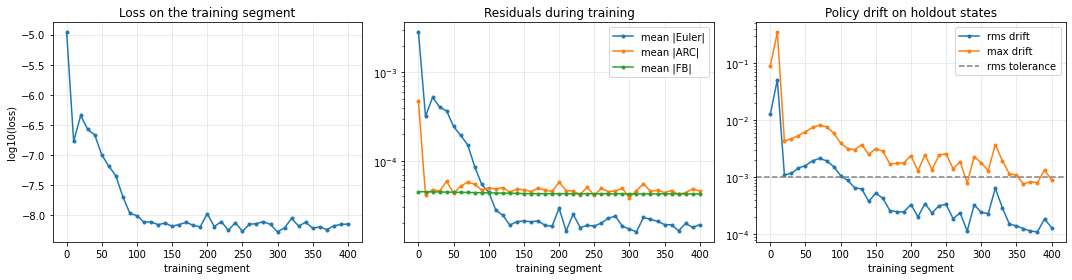

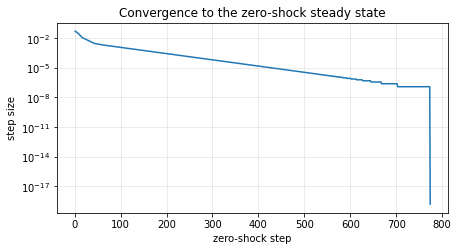

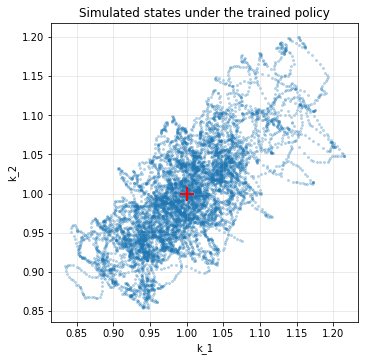

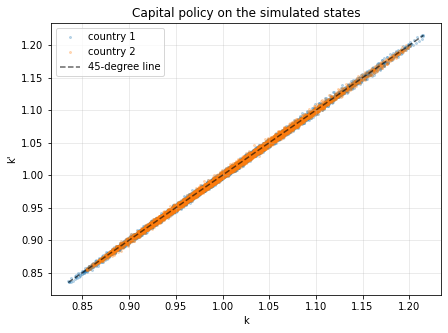

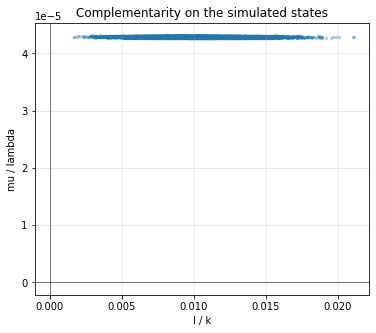

notebook wall-clock time: 3.2 min


In [12]:
seg = history["segment"]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(seg, np.log10(np.maximum(history["loss"], 1e-30)), marker="o", ms=3)
ax[0].set_xlabel("training segment"); ax[0].set_ylabel("log10(loss)"); ax[0].set_title("Loss on the training segment")
ax[1].plot(seg, history["mean_abs_euler"], marker="o", ms=3, label="mean |Euler|")
ax[1].plot(seg, history["mean_abs_arc"], marker="o", ms=3, label="mean |ARC|")
ax[1].plot(seg, history['mean_abs_fb'], marker='o', ms=3, label='mean |FB|')
ax[1].set_yscale("log"); ax[1].set_xlabel("training segment"); ax[1].set_title("Residuals during training"); ax[1].legend()
ax[2].plot(seg, history["policy_drift_rms"], marker="o", ms=3, label="rms drift")
ax[2].plot(seg, history["policy_drift_max"], marker="o", ms=3, label="max drift")
ax[2].axhline(TIME_INVARIANCE_TOL_RMS, ls="--", color="gray", label="rms tolerance")
ax[2].set_yscale("log"); ax[2].set_xlabel("training segment"); ax[2].set_title("Policy drift on holdout states"); ax[2].legend()
for a in ax:
    a.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

if len(zero_shock_result["distances"]) > 0:
    plt.figure(figsize=(7, 3.5))
    plt.plot(np.arange(1, len(zero_shock_result["distances"]) + 1), zero_shock_result["distances"])
    plt.yscale("log"); plt.xlabel("zero-shock step"); plt.ylabel("step size"); plt.title("Convergence to the zero-shock steady state")
    plt.grid(True, alpha=0.3); plt.show()

X_plot = X_eval_ergodic
X_plot_np = X_plot.numpy()
kp_plot = policy(X_plot, model)[0].numpy()

if N_COUNTRIES >= 2:
    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(X_plot_np[:, 0], X_plot_np[:, 1], s=4, alpha=0.25)
    plt.plot([1], [1], "r+", ms=14, mew=2)
    plt.xlabel("k_1"); plt.ylabel("k_2"); plt.title("Simulated states under the trained policy")
    plt.grid(True, alpha=0.3); plt.show()

plt.figure(figsize=(7, 5))
for j in range(N_COUNTRIES):
    plt.scatter(X_plot_np[:, j], kp_plot[:, j], s=4, alpha=0.25, label=f"country {j + 1}")
lo, hi = X_plot_np[:, :N_COUNTRIES].min(), X_plot_np[:, :N_COUNTRIES].max()
plt.plot([lo, hi], [lo, hi], "k--", alpha=0.6, label="45-degree line")
plt.xlabel("k"); plt.ylabel("k'"); plt.title("Capital policy on the simulated states"); plt.legend()
plt.grid(True, alpha=0.3); plt.show()

_, lam_p, mu_p, _, ifrac_p = policy(X_plot, model)
plt.figure(figsize=(6, 5))
plt.scatter(ifrac_p.numpy().ravel(), (mu_p.numpy() / lam_p.numpy()).ravel(), s=5, alpha=0.3)
plt.axhline(0, color="k", lw=0.5); plt.axvline(0, color="k", lw=0.5)
plt.xlabel("I / k"); plt.ylabel("mu / lambda"); plt.title("Complementarity on the simulated states")
plt.grid(True, alpha=0.3); plt.show()

print(f"notebook wall-clock time: {(time.perf_counter() - T_NOTEBOOK_START) / 60:.1f} min")

## How to use

`RUN_MODE = "teaching"` is the committed default and the preset the stored outputs come from. In class, set `RUN_MODE = "smoke"` in the first cell: about a minute on a laptop, residuals an order of magnitude larger, same code path. `production` is three times the teaching budget with wider segments.

`SAMPLING_MODE = "exogenous"` trains on uniform draws from the wide box instead of simulated states, for the comparison of Session 4. `N_COUNTRIES` can be raised; the network, the quadrature and the residuals are written for general $N$. The comparison in section 9 needs $N = 2$.

The companion notebook `05_01_IRBC_DEQN_smooth.ipynb` drops the irreversibility constraint and the multipliers; everything else is shared.